In [52]:
# Import bibliotek
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional, Input
from keras.optimizers import SGD, Adam
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from keras.losses import Huber

In [53]:
# Funkcje pomocnicze: wykres predykcji modelu, metryki oceny modelu RMSE i MAE)
def plot_predictions(test,predicted):
  plt.plot(test, color='red',label='Real IBM Stock Price')
  plt.plot(predicted, color='blue',label='Predicted IBM Stock Price')
  plt.title('IBM Stock Price Prediction')
  plt.xlabel('Time')
  plt.ylabel('IBM Stock Price')
  plt.legend()
  plt.show()

def return_rmse(test, predicted):
  rmse = math.sqrt(mean_squared_error(test, predicted))
  print("-" * 30)
  print("Błąd średniokwadratowy modelu {:.2f}.".format(rmse))
  print("-" * 30)

def return_mae(test, predicted):
  mae = mean_absolute_error(test, predicted)
  mape = mean_absolute_percentage_error(test, predicted) * 100
  print("Średni błąd bezwzględny: {:.2f}.".format(mae))
  print("Średni błąd bezwzględny procentowy: {:.2f}%".format(mape))
  print("-" * 30)

In [54]:
# Wczytanie danych
dataset = pd.read_csv('IBM_2006-01-01_to_2018-01-01.csv', index_col='Date', parse_dates=[ 'Date'])
dataset.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM


In [55]:
# Ustawiamy zbiory trenujące i testowe oraz szukamy brakujących wartości
training_set = dataset[:'2016'].iloc[:,1:2].values
test_set = dataset ['2017':]. iloc[:,1:2].values

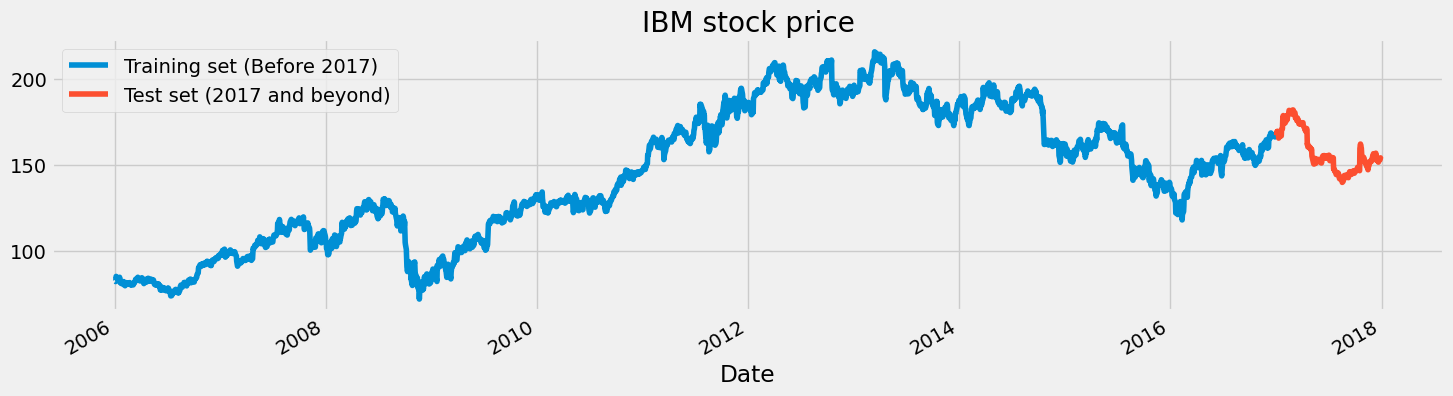

In [56]:
# Wizualizacja danych
dataset["Close"][:'2016'].plot(figsize=(16,4),legend=True)
dataset["Close"]['2017':].plot(figsize=(16,4),legend=True)
plt.legend(['Training set (Before 2017)','Test set (2017 and beyond)'])
plt.title('IBM stock price')
plt.show()

In [57]:
# Normalizacja danych trenujących
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

In [58]:
# Tworzymy strukturę danych z 60 krokami czasowymi i 1 wyjściem
x_train = []
y_train = []
for i in range(60,2769):
  x_train.append(training_set_scaled[i-60:i,0])
  y_train.append(training_set_scaled[i,0])
x_train, y_train = np.array(x_train), np.array(y_train)

In [59]:
# Przekształcanie x_train w celu zapewnienia wydajnego modelowania
x_train = np.reshape(x_train, (x_train.shape[0],x_train.shape[1],1))

In [61]:
# Architektura LSTM, sieć regresyjna, predykująca
regressor = Sequential()
# Warstwa wejściowa
regressor.add(Input(shape=(x_train.shape[1], 1)))
# Pierwsza warstwa LSTM
regressor.add(LSTM(units=1, return_sequences=True))
regressor.add(Dropout(0.2))
# Druga warstwa LSTM z regularyzacją Dropout
regressor.add(LSTM(units=10, return_sequences=True))
regressor.add(Dropout(0.2))
# Trzecia warstwa LSTM z regularyzacją Dropout
regressor.add(LSTM(units=100, return_sequences=True))
regressor.add(Dropout(0.2))
# Czwarta warstwa LSTM z regularyzacją Dropout
regressor.add(LSTM(units=1000))
regressor.add(Dropout(0.2))
# Warstwa wyjściowa
regressor.add(Dense(units=1))

# Ustawaimy funkcję optymalizującą wagi (uczącą) i funkcję straty
regressor.compile(optimizer='rmsprop',loss='mean_squared_error')

# Trenujemy sieć, ustawiamy ilość epok i ilość podawanych próbek ze zbioru trenującego
#regressor.fit(x_train,y_train,epochs=50,batch_size=32)

# Wersja treningu z mechanizmem Early Stopping zapobiegającym przeuczeniu się sieci
# (zakomentować powyższe, odkomentować poniższe)
early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
regressor.fit(x_train, y_train, epochs=100, batch_size=50, callbacks=[early_stop])

Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 0.1928
Epoch 2/100
 3/55 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0157

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0246
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0156
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0109
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0095
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0078
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0075
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0067
Epoch 9/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0069
Epoch 10/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0064
Epoch 11/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 0.0060
Epoch 12/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0056
Epoch 13/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0049
Epoch 14/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0048
Epoch 15/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0050
Epoch 16/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0045


In [62]:
# Teraz przygotujemy zestaw testowy w podobny sposób, jak zestaw treningowy.
dataset_total = pd.concat((dataset["Close"][:'2016'],dataset["High"]['2017':]),axis=0)
inputs = dataset_total[len(dataset_total)-len(test_set) - 60:].values
inputs = inputs.reshape(-1,1)
inputs = sc.transform(inputs)

In [63]:
# Przygotowanie x_testu i predykcja cen akcji
x_test = []
for i in range(60,311):
  x_test.append(inputs[i-60:i,0])
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0],x_test.shape[1],1))
predicted_stock_price = regressor.predict(x_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step


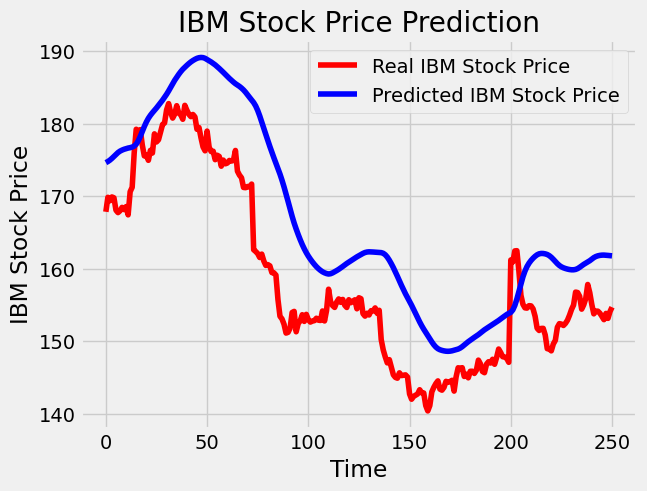

In [64]:
# Wizualizacja wyników dla sieci LSTM
plot_predictions(test_set,predicted_stock_price)

In [65]:
return_rmse(test_set,predicted_stock_price)
return_mae(test_set,predicted_stock_price)

------------------------------
Błąd średniokwadratowy modelu 9.37.
------------------------------
Średni błąd bezwzględny: 8.34.
Średni błąd bezwzględny procentowy: 5.30%
------------------------------


In [ ]:
# Architektura z bramką GRU
regressorGRU = Sequential()
# Warstwa wejściowa
regressorGRU.add (Input(shape=(x_train.shape[1], 1)))
# Pierwsza warstwa GRU z regularyzacją Dropout
regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Druga warstwa GRU z regularyzacją Dropout
regressorGRU.add (GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Trzecia warstwa GRU z regularyzacją Dropout
regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Czwarta warstwa GRU z regularyzacją Dropout
regressorGRU.add(GRU(units=50, activation='tanh'))
regressorGRU.add(Dropout(0.2))
# Warstwa wyjściowa
regressorGRU.add(Dense(units=1))

# Ustawaimy funkcję optymalizującą wagi (uczącą) i funkcję straty
regressorGRU.compile(optimizer='rmsprop', loss='mean_squared_error')

# Trenujemy sieć, ustawiamy ilość epok i ilość podawanych próbek ze zbioru trenującego
# wersja bez Early Stopping
#regressorGRU.fit(X_train,y_train, epochs=50,batch_size=32)

# Wersja treningu z mechanizmem Early Stopping zapobiegającym przeuczeniu się sieci
# (zakomentować powyższe, odkomentować poniższe)
early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
regressorGRU. fit(x_train, y_train, epochs=100, batch_size=32, callbacks=[early_stop])

In [ ]:
# Przygotowanie x_test i przewidywanie cen
x_test = []
for i in range(60,311):
  x_test.append(inputs[i-60:i,0])
x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0],x_test.shape[1],1))
GRU_predicted_stock_price = regressorGRU.predict(x_test)
GRU_predicted_stock_price = sc.inverse_transform(GRU_predicted_stock_price)

In [ ]:
# Wizualizacja wyników dla sieci GRU
plot_predictions(test_set,GRU_predicted_stock_price)

In [ ]:
# Ocena modelu
return_rmse(test_set,GRU_predicted_stock_price)
return_mae(test_set,GRU_predicted_stock_price)